# **Predicción de Calidad del Vino (Core)**

**Objetivo:** Utilizar técnicas de clasificación aprendidas hasta el momento para predecir la calidad del vino basándose en características físico-químicas. Este ejercicio permitirá aplicar conceptos como la selección de características, preprocesamiento de datos, entrenamiento y evaluación de modelos de clasificación, y análisis de resultados mediante métricas y visualizaciones.

**Descripción del Dataset:** Este conjunto de datos contiene información sobre distintas características físico-químicas de muestras de vino tinto y su calidad asociada. Las características incluyen acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre, dióxido de azufre total, densidad, pH, sulfatos y alcohol. La calidad del vino está clasificada en una escala del 0 al 10.

# **1. Carga y Exploración de Datos:**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

**Cargar el dataset y revisar su estructura básica.**

In [3]:
# Cargar dataset
df = pd.read_csv('/content/drive/MyDrive/WineQT.csv')

display(df.head())
print()
display(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


**Exploración Inicial**
(Revisar estructura básica)

In [4]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(1143, 13)


In [5]:
print("\nNúmero de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


Número de filas: 1143
Número de columnas: 13


In [6]:
# Mostrar la información del DataFrame
print("\nInformación del DataFrame:")
print(df.info())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None


In [7]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


**Diccionario inicial de variables, nulos y duplicados**

In [8]:
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Inicial": df.dtypes.values,
    "Valores No Nulos": df.count().values,
    "Valores Nulos": df.isnull().sum().values,
    "Porcentaje Nulos": (df.isnull().sum().values / len(df) * 100).round(2),
    "Valores Únicos": df.nunique().values
})

display(diccionario)

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

,Variable,Tipo Inicial,Valores No Nulos,Valores Nulos,Porcentaje Nulos,Valores Únicos
0,fixed acidity,float64,1143,0,0.0,91
1,volatile acidity,float64,1143,0,0.0,135
2,citric acid,float64,1143,0,0.0,77
3,residual sugar,float64,1143,0,0.0,80
4,chlorides,float64,1143,0,0.0,131
5,free sulfur dioxide,float64,1143,0,0.0,53
6,total sulfur dioxide,float64,1143,0,0.0,138
7,density,float64,1143,0,0.0,388
8,pH,float64,1143,0,0.0,87
9,sulphates,float64,1143,0,0.0,89



Cantidad de filas duplicadas:
0


**Estadistica Descriptiva**

In [9]:
# Mostrar la información estadistica del DataFrame
print("\nEstadística descriptiva Columnas numericas:")
display(df.describe())


Estadística descriptiva Columnas numericas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


**Distribución de la variable objetivo "quality"**


Distribución de la variable quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64




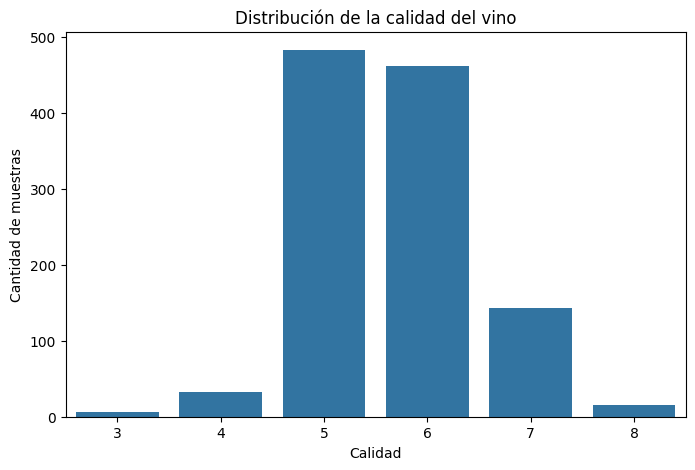




Análisis: 

La distribución de la variable quality nos muestra una concentración muy marcada en las calidades 5 y 6, que reúnen 945 de las 1.143 observaciones del dataset. En contraste, 
las categorías 3, 4 y 8 aparecen con muy poca frecuencia, sumando solo 55 registros en total. Siendo esta diferencia importante para el objetivo del estudio el cual es predecir 
correctamente la calidad del vino a partir de sus características físico-químicas. 
Si el modelo aprende principalmente los patrones asociados a las categorías 5 y 6, podría alcanzar una exactitud aparentemente alta unicamente porque son las clases más
frecuentes, sin embargo posteriormente se evidenciarían dificultades para reconocer vinos de calidad baja o alta. Por esta razón, durante la evaluación 
no se considerará únicamente la métrica accuracy. También se analizarán precision, recall, F1-score y las matrices de confusión, con el propósito de verificar si los modelos 
son capaces de identificar adecuadamente todas las 

In [10]:
print("\nDistribución de la variable quality:")
print(df["quality"].value_counts().sort_index())
print()
print()
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="quality")
plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Cantidad de muestras")
plt.show()
print()
print()
print("""
Análisis:

La distribución de la variable quality nos muestra una concentración muy marcada en las calidades 5 y 6, que reúnen 945 de las 1.143 observaciones del dataset. En contraste,
las categorías 3, 4 y 8 aparecen con muy poca frecuencia, sumando solo 55 registros en total. Siendo esta diferencia importante para el objetivo del estudio el cual es predecir
correctamente la calidad del vino a partir de sus características físico-químicas.
Si el modelo aprende principalmente los patrones asociados a las categorías 5 y 6, podría alcanzar una exactitud aparentemente alta unicamente porque son las clases más
frecuentes, sin embargo posteriormente se evidenciarían dificultades para reconocer vinos de calidad baja o alta. Por esta razón, durante la evaluación
no se considerará únicamente la métrica accuracy. También se analizarán precision, recall, F1-score y las matrices de confusión, con el propósito de verificar si los modelos
son capaces de identificar adecuadamente todas las categorías de calidad y no solamente aquellas con mayor cantidad de ejemplos.
""")

**Distribución de las variables físico-químicas**

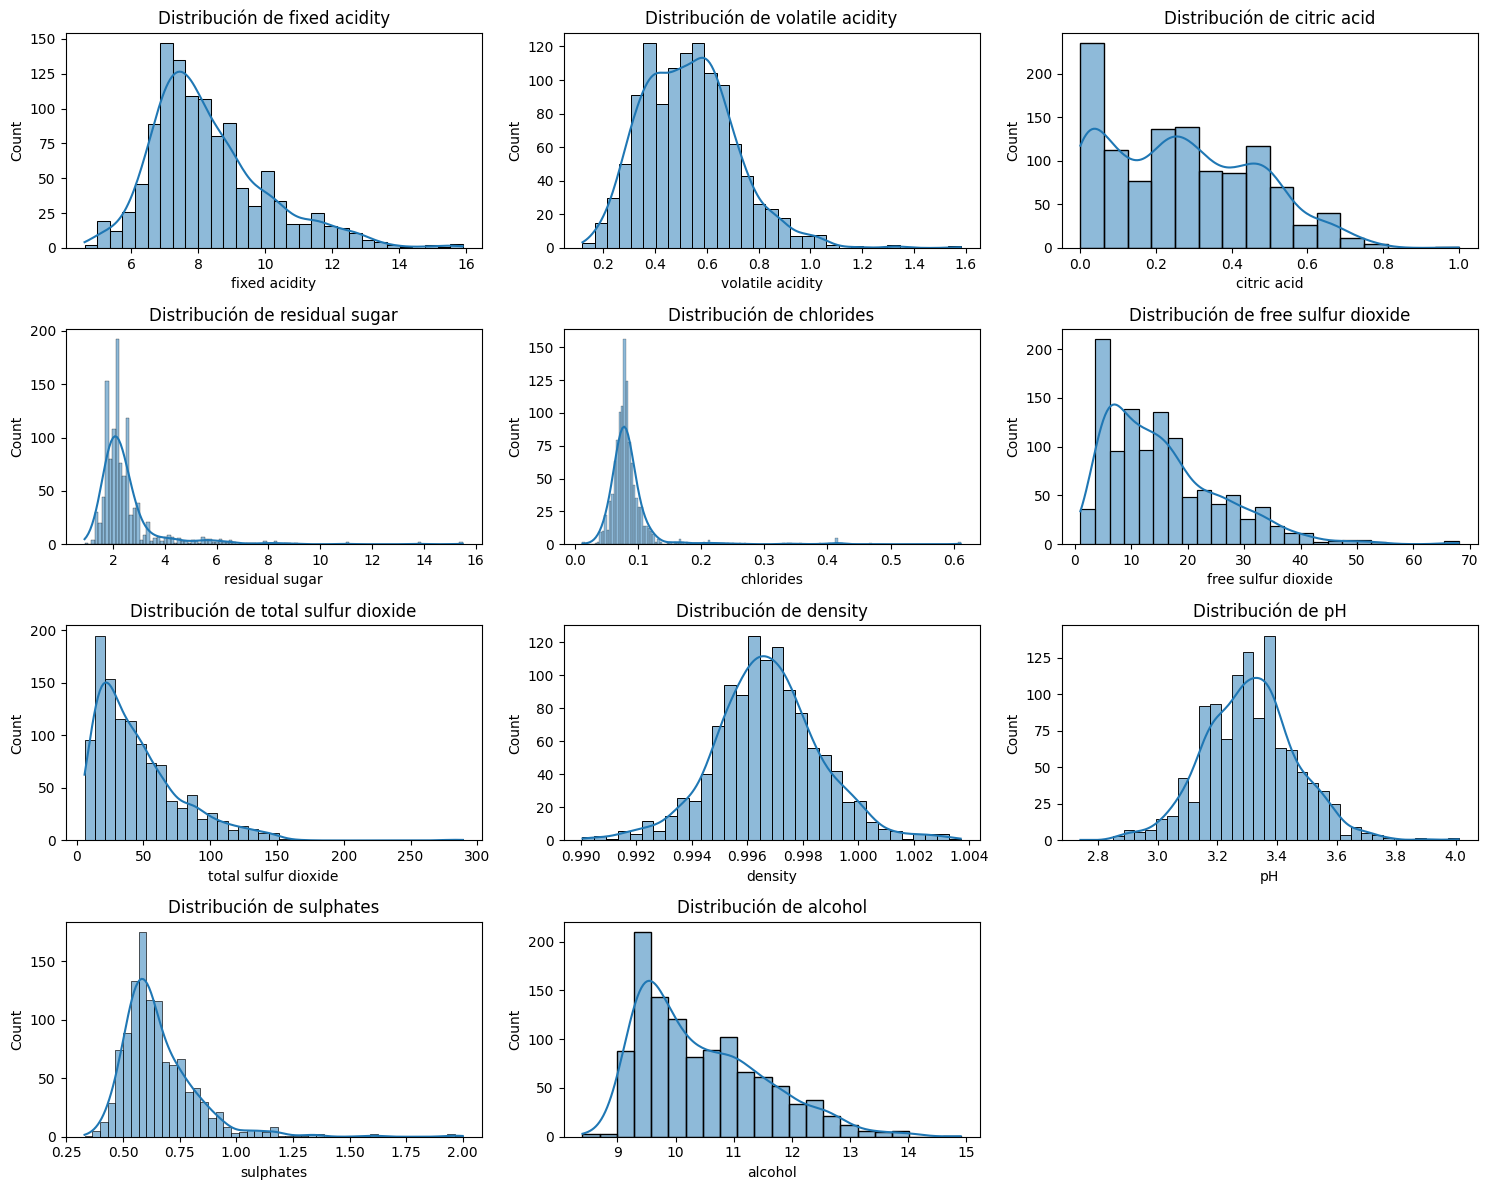





Podemos observar en los histogramas que las características físico-químicas de los vinos no siguen un mismo patrón de distribución. Algunas variables, como pH y density, 
presentan una concentración importante de observaciones en rangos muy específicos, lo que nos indica que la mayoría de los vinos analizados comparten valores similares en 
estos atributos. Por otra parte, las variables como alcohol, residual sugar, chlorides, free sulfur dioxide y total sulfur dioxide presentan una mayor dispersión y 
algunos valores extremos alejados del comportamiento predominante.
Siendo estas diferencias relevantes ante el objetivo de predecir la calidad del vino basándose en características físico-químicas que puedan explicarse a partir de la 
combinación de sus características químicas. Sin embargo, no todas las variables aportan información de la misma forma. Por ejemplo, alcohol muestra una variabilidad 
considerable entre muestras, mientras que pH y density presentan rangos mucho más acot

In [11]:
variables_graficar = df.drop(columns=["Id", "quality"]).columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15,12)
)

axes = axes.flatten()

for i, col in enumerate(variables_graficar):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {col}")

# Eliminar gráfico vacío si queda una celda sin uso
for j in range(len(variables_graficar), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
print()
print()
print("""

Podemos observar en los histogramas que las características físico-químicas de los vinos no siguen un mismo patrón de distribución. Algunas variables, como pH y density,
presentan una concentración importante de observaciones en rangos muy específicos, lo que nos indica que la mayoría de los vinos analizados comparten valores similares en
estos atributos. Por otra parte, las variables como alcohol, residual sugar, chlorides, free sulfur dioxide y total sulfur dioxide presentan una mayor dispersión y
algunos valores extremos alejados del comportamiento predominante.
Siendo estas diferencias relevantes ante el objetivo de predecir la calidad del vino basándose en características físico-químicas que puedan explicarse a partir de la
combinación de sus características químicas. Sin embargo, no todas las variables aportan información de la misma forma. Por ejemplo, alcohol muestra una variabilidad
considerable entre muestras, mientras que pH y density presentan rangos mucho más acotados.
Estas diferencias podrían afectar especialmente a algoritmos que calculan similitud o distancia entre observaciones. Por esta razón, antes de entrenar KNN y
Regresión Logística se deberá aplicar un proceso de escalamiento, con la finalidad que variables con valores numéricamente más altos no influyen de manera desproporcionada
en la clasificación.
""")

In [12]:
# Resumen estadístico de las variables numéricas

resumen_estadistico = df.describe().T

display(
    resumen_estadistico[
        ["mean","std","min","25%","50%","75%","max"]
    ].round(3)
)
print("""

La tabla descriptiva nos permite observar diferencias importantes en la escala y dispersión de las variables.
Variables como pH y density presentan rangos más acotados, otras como total sulfur dioxide, free sulfur dioxide
y alcohol muestran mayor variabilidad. Esto también se vio reflejado en los histogramas, es decir, variables con
distribuciones concentradas alrededor de valores centrales y otras asimétricas con presencia de valores extremos.
Este comportamiento sugiere que las variables no aportan información bajo la misma escala numérica. Razon por la
que será necesario aplicar escalamiento antes de entrenar modelos sensibles a la distancia.
""")

,mean,std,min,25%,50%,75%,max
fixed acidity,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,0.658,0.170,0.330,0.550,0.620,0.730,2.000




La tabla descriptiva nos permite observar diferencias importantes en la escala y dispersión de las variables. 
Variables como pH y density presentan rangos más acotados, otras como total sulfur dioxide, free sulfur dioxide 
y alcohol muestran mayor variabilidad. Esto también se vio reflejado en los histogramas, es decir, variables con 
distribuciones concentradas alrededor de valores centrales y otras asimétricas con presencia de valores extremos.
Este comportamiento sugiere que las variables no aportan información bajo la misma escala numérica. Razon por la 
que será necesario aplicar escalamiento antes de entrenar modelos sensibles a la distancia.



**Asimetría de las variables**

In [13]:
asimetria = pd.DataFrame({
    "Variable": variables_graficar,
    "Skewness": df[variables_graficar].skew().values
}).sort_values(by="Skewness", ascending=False)

display(asimetria)
print()
print()
print("""Este analisis nos permite complementar la información observada previamente. Identificando que variables como chlorides (6,03)
y residual sugar (4,36) presentan una fuerte concentración de observaciones en valores bajos, junto con algunos vinos que registran niveles
considerablemente más altos.
En su contraste, variables como density (0,10) y pH (0,22) muestran distribuciones mucho más equilibradas. Estos datos nos indican que las
características químicas del vino no siguen un comportamiento homogéneo, lo que sugiere la existencia de relaciones complejas entre las
variables predictoras y la calidad final del producto.""")

,Variable,Skewness
4,chlorides,6.026360
3,residual sugar,4.361096
9,sulphates,2.497266
6,total sulfur dioxide,1.665766
5,free sulfur dioxide,1.231261
0,fixed acidity,1.044930
10,alcohol,0.863313
1,volatile acidity,0.681547
2,citric acid,0.371561
8,pH,0.221138




Este analisis nos permite complementar la información observada previamente. Identificando que variables como chlorides (6,03) 
y residual sugar (4,36) presentan una fuerte concentración de observaciones en valores bajos, junto con algunos vinos que registran niveles
considerablemente más altos. 
En su contraste, variables como density (0,10) y pH (0,22) muestran distribuciones mucho más equilibradas. Estos datos nos indican que las 
características químicas del vino no siguen un comportamiento homogéneo, lo que sugiere la existencia de relaciones complejas entre las 
variables predictoras y la calidad final del producto.


**Identificación de valores nulos**

In [14]:
print("\nValores nulos por variable:")
print(df.isnull().sum())
print()
print("""
Se evidencia la ausencia de valores faltantes, lo que nos permite trabajar con las 1.143 observaciones originales
sin necesidad de aplicar técnicas de imputación o eliminar registros.
""")


Valores nulos por variable:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Se evidencia la ausencia de valores faltantes, lo que nos permite trabajar con las 1.143 observaciones originales 
sin necesidad de aplicar técnicas de imputación o eliminar registros.



**Identificación de outliers mediante boxplot.**

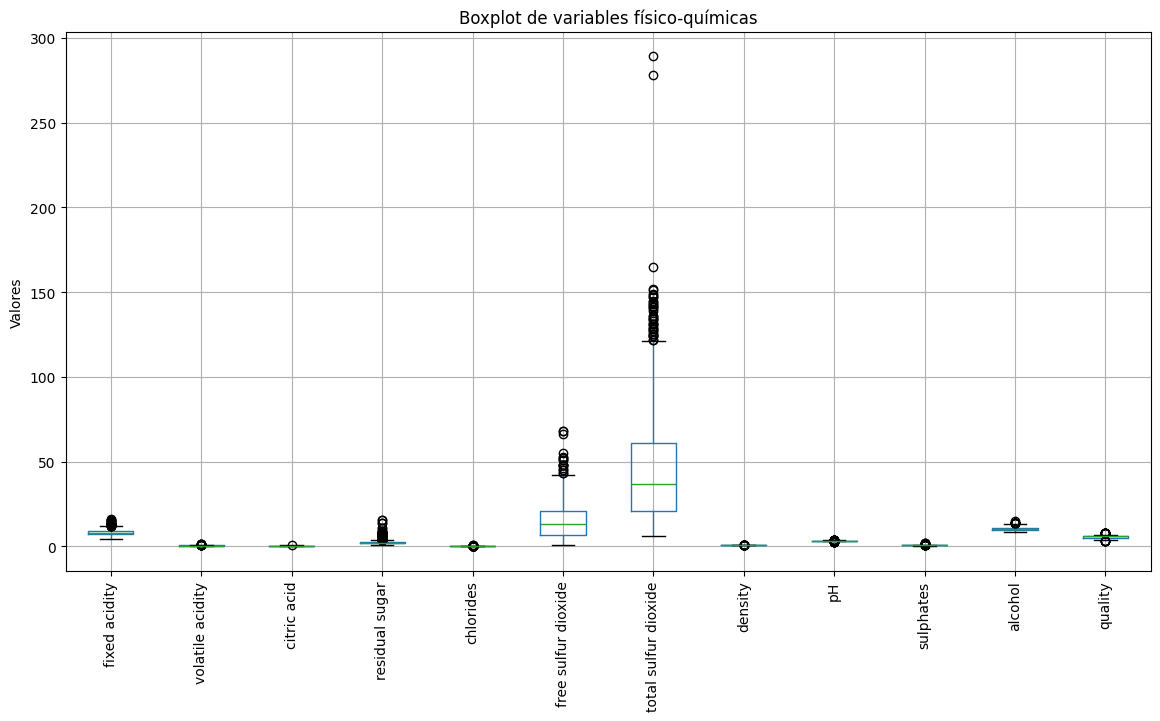



Se puede observar que variables como total sulfur dioxide, free sulfur dioxide, residual sugar, chlorides, sulphates y fixed acidity presentan
observaciones alejadas de la mayor parte de los datos. Lo que nos indica que existen vinos con composiciones químicas poco frecuentes respecto
del comportamiento general de la muestra.



In [15]:
plt.figure(figsize=(14,7))
df.drop(columns=["Id"]).boxplot(rot=90)
plt.title("Boxplot de variables físico-químicas")
plt.ylabel("Valores")
plt.show()

print("""

Se puede observar que variables como total sulfur dioxide, free sulfur dioxide, residual sugar, chlorides, sulphates y fixed acidity presentan
observaciones alejadas de la mayor parte de los datos. Lo que nos indica que existen vinos con composiciones químicas poco frecuentes respecto
del comportamiento general de la muestra.
""")

**Describir las variables y su distribución**

In [16]:
# Distribución de la variable objetivo
print("\nDistribución de la variable quality:")
print(df["quality"].value_counts().sort_index())
print()
print("""
Se vuelve a evidenciar que la variable quality presenta una distribución desbalanceada, concentrada en las categorías 5 y 6.
Esta situación representa un desafío para los modelos de clasificación, ya que podrían favorecer las categorías más frecuentes.
Por ello, además de la exactitud (accuracy), se utilizarán métricas como precision, recall y F1-score para evaluar el desempeño de manera más completa.
""")


Distribución de la variable quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


Se vuelve a evidenciar que la variable quality presenta una distribución desbalanceada, concentrada en las categorías 5 y 6.
Esta situación representa un desafío para los modelos de clasificación, ya que podrían favorecer las categorías más frecuentes. 
Por ello, además de la exactitud (accuracy), se utilizarán métricas como precision, recall y F1-score para evaluar el desempeño de manera más completa.



**Outliers**

**Conteo de outliers mediante método IQR**

In [17]:
X_outliers = df.drop(columns=["Id", "quality"])

Q1 = X_outliers.quantile(0.25)
Q3 = X_outliers.quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (X_outliers < (Q1 - 1.5 * IQR)) |
    (X_outliers > (Q3 + 1.5 * IQR))
)

conteo_outliers = outliers.sum().sort_values(ascending=False)

print("\nCantidad de outliers por variable:")
display(conteo_outliers)
print()
print()
print()
print("""

Se confirma la presencia de valores atípicos en diferentes variables. Se puede observar las mayores concentraciones en las variables
residual sugar (110 casos), chlorides (77), fixed acidity (44) y sulphates (43), siendo estos resultados consistentes con las graficass
revisados previamente, donde se mostraban distribuciones más asimétricas. Aunque se identificaron observaciones alejadas del comportamiento
predominante, se decide mantenerlas porque representan características reales de algunos vinos y podrían aportar información relevante para
explicar diferencias en la variable quality. Esta decisión permitió conservar la variabilidad original de los datos y evaluar cómo los
distintos modelos responden frente a muestras menos frecuentes.""")



Cantidad de outliers por variable:


,0
residual sugar,110
chlorides,77
fixed acidity,44
sulphates,43
total sulfur dioxide,40
density,36
pH,20
free sulfur dioxide,18
volatile acidity,14
alcohol,12







Se confirma la presencia de valores atípicos en diferentes variables. Se puede observar las mayores concentraciones en las variables 
residual sugar (110 casos), chlorides (77), fixed acidity (44) y sulphates (43), siendo estos resultados consistentes con las graficass 
revisados previamente, donde se mostraban distribuciones más asimétricas. Aunque se identificaron observaciones alejadas del comportamiento
predominante, se decide mantenerlas porque representan características reales de algunos vinos y podrían aportar información relevante para
explicar diferencias en la variable quality. Esta decisión permitió conservar la variabilidad original de los datos y evaluar cómo los 
distintos modelos responden frente a muestras menos frecuentes.


**Matriz de correlación**

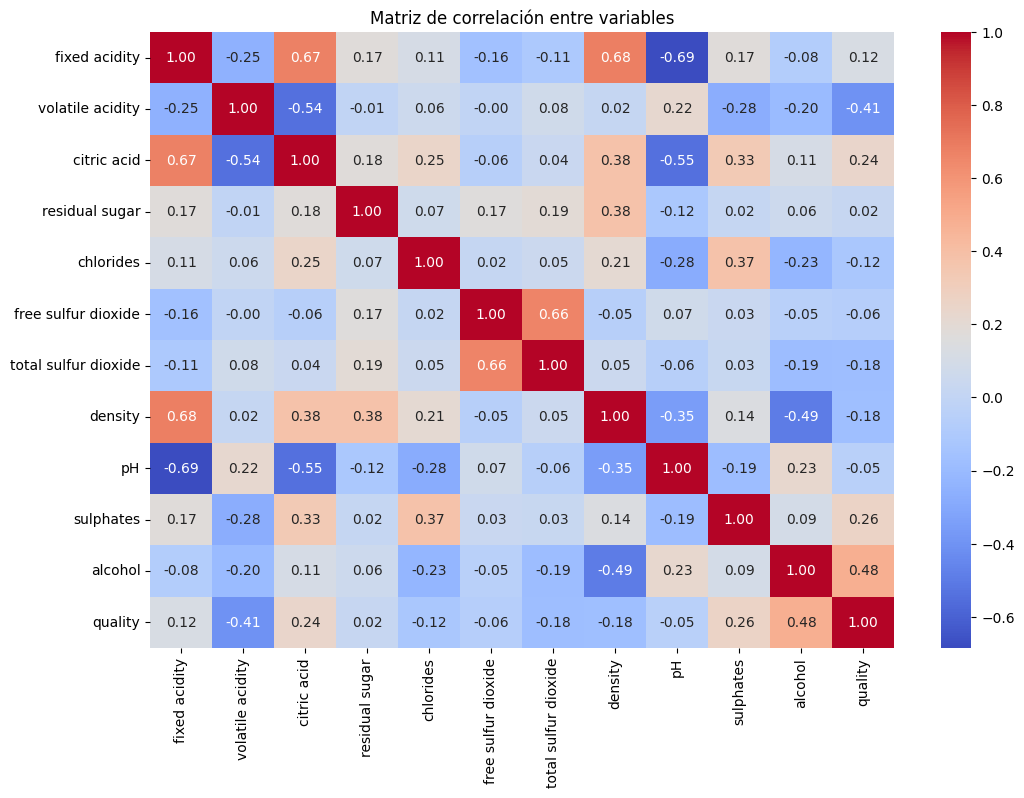





Las variables con mayor relación positiva con la calidad del vino fueron alcohol (0,48), sulphates (0,26) y citric acid (0,24). 
Por el contrario, volatile acidity (-0,41) presentó la asociación negativa más importante, seguida por total sulfur dioxide (-0,18)
y density (-0,18). Estos resultados sugieren que la calidad del vino no depende de una única característica química, sino de la 
combinación de varias variables. Siendo esta la razón, que en las siguientes etapas se evaluará la capacidad de distintos modelos
para capturar simultáneamente estas relaciones y predecir la variable quality.


In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.drop(columns=["Id"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación entre variables")
plt.show()
print()
print()
print("""

Las variables con mayor relación positiva con la calidad del vino fueron alcohol (0,48), sulphates (0,26) y citric acid (0,24).
Por el contrario, volatile acidity (-0,41) presentó la asociación negativa más importante, seguida por total sulfur dioxide (-0,18)
y density (-0,18). Estos resultados sugieren que la calidad del vino no depende de una única característica química, sino de la
combinación de varias variables. Siendo esta la razón, que en las siguientes etapas se evaluará la capacidad de distintos modelos
para capturar simultáneamente estas relaciones y predecir la variable quality.""")

In [19]:
print("\nCorrelación de variables con quality:")
correlacion_quality = (
    df.drop(columns=["Id"])
    .corr()["quality"]
    .drop("quality")
    .sort_values(key=abs, ascending=False)
)
display(correlacion_quality)


Correlación de variables con quality:


,quality
alcohol,0.484866
volatile acidity,-0.407394
sulphates,0.257710
citric acid,0.240821
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
fixed acidity,0.121970
free sulfur dioxide,-0.063260
pH,-0.052453


La exploración inicial permitió verificar que el dataset se encuentra en buenas condiciones para desarrollar modelos de clasificación, ya que se observan 1.143 datos sin valores nulos ni registros duplicados. Asimismo, se pudo evidenciar que la variable Id cumple solo una función de identificación sin aporte de información predictiva que aporte valor sobre la calidad del vino.

En relación con la variable objetivo, se observó un desbalance importante entre categorías. Las calidades 5 (483 registros) y 6 (462 registros) concentran más del 82% de las observaciones, mientras que las categorías 3 (6 registros), 4 (33 registros) y 8 (16 registros) poseen una representación considerablemente menor. Esta distribución nos anticipa una dificultad para que los modelos logren clasificar correctamente las categorías menos frecuentes.

El análisis de distribución evidenció asimetrías y presencia de valores atípicos en variables como residual sugar (110 outliers), chlorides (77), fixed acidity (44) y sulphates (43). Sin embargo, estos registros fueron conservados debido a que representan variabilidad real en la composición química de los vinos y no errores de medición o digitación.

Finalmente, el análisis de correlación mostró que alcohol (r = 0,48) es la variable con mayor asociación positiva con la calidad, seguida por sulphates (r = 0,26) y citric acid (r = 0,24). En contraste, volatile acidity (r = -0,41) presentó la relación negativa más relevante. Estos resultados sugieren que la calidad del vino depende de la interacción de múltiples características físico-químicas.

# **2. Preprocesamiento de Datos:**

Para esta etapa se definieron las variables predictoras **X** y la variable objetivo **Y**. Se procedera a la eliminación de la columna Id al no representa una característica físico-química del vino y la decisión de mantenerla podría inducir errores en el modelo, afectando negativamente el aprendizaje.

En la etapa de analisis inicial, se verificó que todas las variables predictoras son numéricas, por lo que no sera necesario aplicar técnicas de codificación de variables categóricas, permitiendonos así, trabajar directamente con los algoritmos de clasificación seleccionados.

La división de datos se realizará en 70% para entrenamiento y 30% para prueba. Utilizando **stratify=y** debido al desbalance previamente observado en la variable quality, con esto se quiere lograr conservar una proporción similar de clases en ambos conjuntos.

Para finalmente, aplicar escalamiento mediante StandardScaler, ajustando el transformador solo con los datos de entrenamiento y aplicándolo posteriormente al conjunto de prueba. con esta decisión se quiere evitar la fuga de información, siendo necesaria para modelos como KNN y Regresión Logística que son sensibles a la escala de las variables.

**Selección de características y variable objetivo**

In [20]:
# Se elimina Id porque es un identificador y no aporta información predictiva
df_modelo = df.drop(columns=["Id"])

In [21]:
# Variables predictoras
X = df_modelo.drop(columns=["quality"])

# Variable objetivo
y = df_modelo["quality"]

print("""Variables predictoras:
""")
print(X.columns)
print()
print("""\nVariable objetivo:
""")
print(y.name)

Variables predictoras:

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


Variable objetivo:

quality


Se definieron las 11 caracteristicas físico-químicas disponibles del vino como  variables predictoras. La variable quality se define como objetivo, dado que representa la clasificación de calidad asignada a cada vino. Se excluye del análisis la variable Id dado su escaso valor con el objetivo.

**Verificación de variables categóricas**

**Seleccionar características importantes para la clasificación.**

In [22]:
print()
print("Tipos de datos de las variables predictoras:")
print(X.dtypes)
print()
categoricas = X.select_dtypes(include=["object", "category"]).columns
print("\nVariables categóricas encontradas:")
print(list(categoricas))


Tipos de datos de las variables predictoras:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


Variables categóricas encontradas:
[]


Se evidencia que todas las variables predictoras son numéricas y se encuentran almacenadas en formato float64. No se identificaron variables categóricas que requirieran procesos de codificación o transformación adicionales.

**División en entrenamiento y prueba**

In [23]:
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

# Escalamiento independiente para modelos sensibles a escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tamaño entrenamiento: (914, 11)
Tamaño prueba: (229, 11)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

print("\nDistribución de quality en entrenamiento:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución de quality en prueba:")
print(y_test.value_counts(normalize=True).sort_index())

Tamaño del conjunto de entrenamiento: (914, 11)
Tamaño del conjunto de prueba: (229, 11)

Distribución de quality en entrenamiento:
quality
3    0.005470
4    0.028446
5    0.422319
6    0.404814
7    0.124726
8    0.014223
Name: proportion, dtype: float64

Distribución de quality en prueba:
quality
3    0.004367
4    0.030568
5    0.423581
6    0.401747
7    0.126638
8    0.013100
Name: proportion, dtype: float64


El conjunto de datos fue dividido en una proporción de 80% para entrenamiento (914 registros) y 20% para prueba (229 registros). Adicionalmente, se utilizó la opción stratify, con el propósito de conservar la distribución original de las categorías de calidad en ambos subconjuntos. Se busca que el modelo aprenda bajo condiciones representativas, considerando que las categorías no se distribuyen uniformemente, y asimismo, reducir el riesgo de que algunas clases queden subrepresentadas.

**Escalamiento de características**

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,-0.012101,0.388684,-0.109113,-0.264324,0.609897,-0.643427,-0.236286,-0.299229,-1.039511,-0.731171,-0.608473
357,1.248615,-1.626485,0.761211,-0.600511,-0.208555,-0.942939,-0.719059,0.454173,-0.649907,2.263064,0.330960
385,0.675563,-0.394993,1.119580,3.181593,-0.468065,-1.042777,-0.869926,1.082009,-0.649907,0.420458,0.518847
1057,-1.559342,0.500638,-1.235414,-0.852652,-0.148669,-0.942939,-0.990619,-0.916601,2.272119,-0.212938,-0.326643
161,0.331731,0.332708,1.170776,-0.432418,4.981632,1.153646,1.061167,-0.173662,-1.753784,5.487625,-0.890303


Ante las diferencias presentes en el escalamiento de las variables, se aplicó una estandarización mediante StandardScaler, utilizando los datos de entrenamiento para ajustar la transformación que posteriormente se aplica al conjunto de prueba. Este procedimiento permite que variables con rangos más amplios, no influyan desproporcionada sobre otras variables con escalas menores.

# **Conclusión:**

Las acciones realizadas durante el preprocesamiento se justifcan en los resultados obtenidos en la exploración de los datos.
Se decide la conservación de los valores atípicos identificados, ya que corresponden a observaciones reales del proceso de producción y composición química de los vinos analizados.

La utilización de una partición estratificada nos permite preservar la distribución original de la variable quality (importante por la concentración de registros en las categorías 5 y 6.)

Por último, la aplicación de escalamiento busca garantizar que todas las variables contribuyan en condiciones comparables al proceso de clasificación, evitando que las diferencias de magnitud observadas entre características influyan indebidamente en el aprendizaje de los modelos.

# **3. Entrenamiento de Modelos de Clasificación**

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**3.1 MODELO KNN**

In [27]:
print()
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

parametros_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametros_knn,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

modelo_knn = grid_knn.best_estimator_
y_pred_knn = modelo_knn.predict(X_test)
print()
print("""Mejores hiperparámetros KNN:
""")
print(grid_knn.best_params_)

print("\nMejor F1 macro promedio en validación cruzada:")
print(round(grid_knn.best_score_, 4))
y_pred_knn = modelo_knn.predict(X_test)

print()
print()
print(""" Análisis Modelo KNN

El proceso identificó como mejor configuración el uso de 13 vecinos, distancia Manhattan y ponderación por distancia, alcanzando un F1 macro promedio de 0,3123.
Lo que nos sugiere que la clasificación basada en similitud entre observaciones puede capturar parte de los patrones presentes en las características físico-químicas
del vino. La selección de una métrica Manhattan indica que las diferencias acumuladas entre variables como alcohol, sulphates, volatile acidity y density aportan
información que sera útil para distinguir niveles de calidad. Asimismo, la utilización de ponderación por distancia permite otorgar mayor relevancia a las observaciones
más cercanas, reduciendo la influencia de vinos con características menos similares..""")



Mejores hiperparámetros KNN:

{'knn__metric': 'manhattan', 'knn__n_neighbors': 13, 'knn__weights': 'distance'}

Mejor F1 macro promedio en validación cruzada:
0.3123


 Análisis Modelo KNN

El proceso identificó como mejor configuración el uso de 13 vecinos, distancia Manhattan y ponderación por distancia, alcanzando un F1 macro promedio de 0,3123.
Lo que nos sugiere que la clasificación basada en similitud entre observaciones puede capturar parte de los patrones presentes en las características físico-químicas
del vino. La selección de una métrica Manhattan indica que las diferencias acumuladas entre variables como alcohol, sulphates, volatile acidity y density aportan 
información que sera útil para distinguir niveles de calidad. Asimismo, la utilización de ponderación por distancia permite otorgar mayor relevancia a las observaciones
más cercanas, reduciendo la influencia de vinos con características menos similares..


**3.2 MODELO RANDOM FOREST**

In [28]:
modelo_base_rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

parametros_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=modelo_base_rf,
    param_grid=parametros_rf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

modelo_rf = grid_rf.best_estimator_
y_pred_rf = modelo_rf.predict(X_test)

print("Mejores hiperparámetros Random Forest:")
print(grid_rf.best_params_)

print("\nMejor F1 macro promedio en validación cruzada:")
print(round(grid_rf.best_score_, 4))

Mejores hiperparámetros Random Forest:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Mejor F1 macro promedio en validación cruzada:
0.332


La búsqueda de hiperparámetros determinó que la mejor configuración corresponde a un bosque de 100 árboles, sin límite de profundidad, con un mínimo de 5 observaciones para dividir nodos y 2 observaciones por hoja terminal, alcanzando un F1 macro promedio de 0,332. Esta configuración sugiere que la clasificación de la calidad del vino requiere capturar interacciones más complejas entre variables. Factores como alcohol, volatile acidity, sulphates, density y citric acid probablemente no actúan de manera aislada, sino en combinación.
La ausencia de una restricción de profundidad indica que existen patrones de clasificación que requieren múltiples niveles de partición para ser representados adecuadamente.

**3.3 MODELO REGRESIÓN LOGÍSTICA**

In [29]:
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

parametros_log = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__solver": ["lbfgs"]
}

grid_log = GridSearchCV(
    estimator=pipeline_log,
    param_grid=parametros_log,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

modelo_log = grid_log.best_estimator_
y_pred_log = modelo_log.predict(X_test)

print("Mejores hiperparámetros Regresión Logística:")
print(grid_log.best_params_)

print("\nMejor F1 macro promedio en validación cruzada:")
print(round(grid_log.best_score_, 4))

Mejores hiperparámetros Regresión Logística:
{'logreg__C': 10, 'logreg__solver': 'lbfgs'}

Mejor F1 macro promedio en validación cruzada:
0.2895


El mejor desempeño se obtuvo utilizando un parámetro de regularización C igual a 10 y el optimizador lbfgs, alcanzando un F1 macro promedio de 0,2895. Lo que nos indica que existe cierta relación entre las características físico-químicas del vino y su calidad, aunque dicha relación podría no ser completamente lineal. Variables como alcohol, sulphates y volatile acidity muestran asociaciones con la calidad observadas durante el análisis exploratorio, pero probablemente interactúan entre sí de una forma más compleja de lo que un modelo lineal puede representar.

# **4. Evaluación de Modelos**

**4.1 Modelo KNN**

In [30]:
print("MODELO: KNN")
print("="*50)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average="macro", zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average="macro", zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average="macro", zero_division=0)

print("Accuracy:", round(accuracy_knn,3))
print("Precision Macro:", round(precision_knn,3))
print("Recall Macro:", round(recall_knn,3))
print("F1 Macro:", round(f1_knn,3))

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

MODELO: KNN
Accuracy: 0.694
Precision Macro: 0.349
Recall Macro: 0.336
F1 Macro: 0.338

Informe de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.75      0.77      0.76        97
           6       0.64      0.76      0.70        92
           7       0.70      0.48      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.69       229
   macro avg       0.35      0.34      0.34       229
weighted avg       0.66      0.69      0.67       229



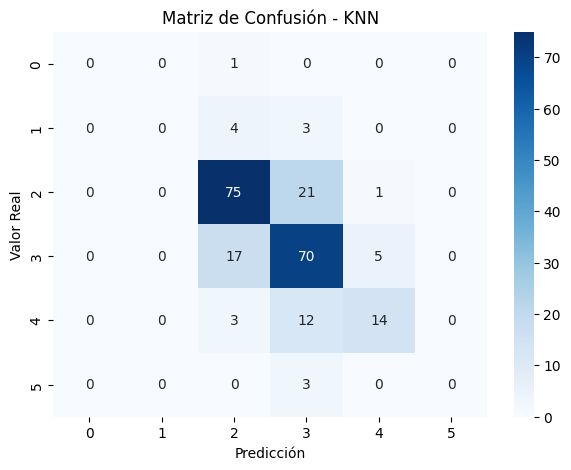

In [31]:
# Matriz de Confusión KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

El modelo KNN obtuvo un Accuracy de 0,694 y un F1 Macro de 0,338. Aunque presenta el mayor porcentaje global de aciertos, su desempeño se concentra principalmente en las categorías más frecuentes del conjunto de datos (calidades 5 y 6.)

La matriz de confusión evidencia dificultades para identificar correctamente las clases con menor representación, lo que reduce el equilibrio general del modelo entre todas las categorías. Este comportamiento es consistente con la naturaleza de KNN, ya que la clasificación depende directamente de la similitud entre observaciones cercanas.

En consecuencia, KNN demuestra una buena capacidad para reconocer patrones dominantes en los datos, aunque presenta limitaciones para representar adecuadamente las categorías menos frecuentes de calidad del vino.

**4.2 MODELO RANDOM FOREST**

In [32]:
print("MODELO: RANDOM FOREST")
print("="*50)

# Asegurar predicción del modelo
y_pred_rf = modelo_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)

print("Accuracy:", round(accuracy_rf, 3))
print("Precision Macro:", round(precision_rf, 3))
print("Recall Macro:", round(recall_rf, 3))
print("F1 Macro:", round(f1_rf, 3))

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

MODELO: RANDOM FOREST
Accuracy: 0.664
Precision Macro: 0.484
Recall Macro: 0.381
F1 Macro: 0.405

Informe de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.77      0.75        97
           6       0.62      0.66      0.64        92
           7       0.56      0.52      0.54        29
           8       1.00      0.33      0.50         3

    accuracy                           0.66       229
   macro avg       0.48      0.38      0.40       229
weighted avg       0.64      0.66      0.65       229



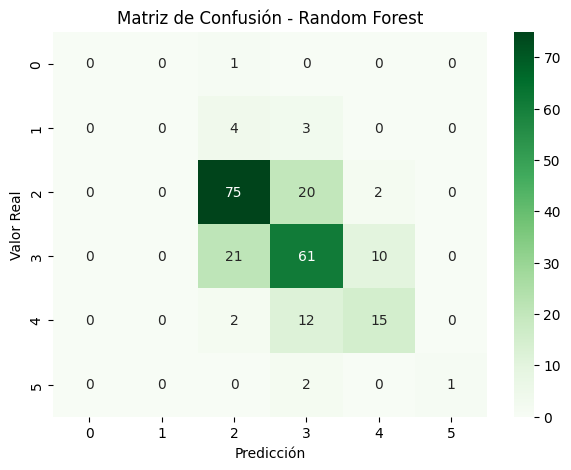

In [33]:
# Matriz de Confusión - Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

Random Forest obtuvo un Accuracy de 0,664 y el mejor F1 Macro de los modelos evaluados (0,405). Este resultado indica un desempeño más equilibrado entre las distintas categorías de calidad, aspecto especialmente relevante en un problema con clases desbalanceadas.

La matriz de confusión muestra una mejor distribución de los aciertos entre las categorías principales y una menor dependencia de las clases mayoritarias. Esto sugiere que el modelo logra capturar relaciones complejas entre las variables físico-químicas del vino, aprovechando interacciones que no son fácilmente representadas mediante enfoques lineales o basados exclusivamente en distancia.

Considerando conjuntamente Accuracy, Precision, Recall y F1 Macro, Random Forest presenta el comportamiento más robusto y consistente para este problema de clasificación multiclase.

**4.3  MODELO REGRESIÓN LOGÍSTICA**

In [34]:
print("MODELO: REGRESIÓN LOGÍSTICA")
print("="*50)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, average="macro", zero_division=0)
recall_log = recall_score(y_test, y_pred_log, average="macro", zero_division=0)
f1_log = f1_score(y_test, y_pred_log, average="macro", zero_division=0)

print("Accuracy:", round(accuracy_log, 3))
print("Precision Macro:", round(precision_log, 3))
print("Recall Macro:", round(recall_log, 3))
print("F1 Macro:", round(f1_log, 3))

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_log, zero_division=0))

MODELO: REGRESIÓN LOGÍSTICA
Accuracy: 0.437
Precision Macro: 0.302
Recall Macro: 0.393
F1 Macro: 0.278

Informe de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.08      0.43      0.13         7
           5       0.74      0.59      0.66        97
           6       0.64      0.29      0.40        92
           7       0.25      0.38      0.30        29
           8       0.10      0.67      0.17         3

    accuracy                           0.44       229
   macro avg       0.30      0.39      0.28       229
weighted avg       0.61      0.44      0.48       229



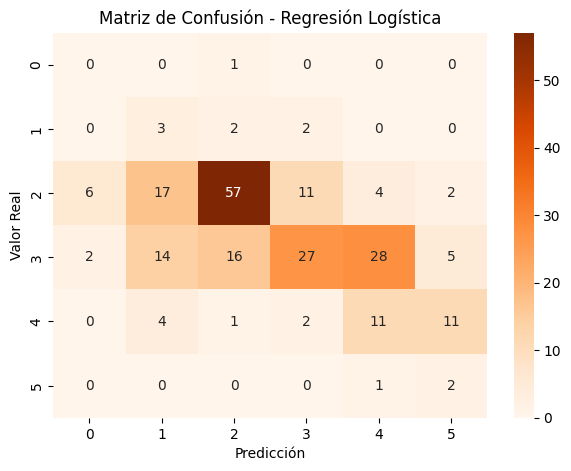

In [35]:
# Matriz de Confusión - Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

La Regresión Logística alcanzó un Accuracy de 0,437 y un F1 Macro de 0,278, siendo el desempeño más bajo entre los modelos evaluados. La matriz de confusión evidencia una mayor dispersión de errores y dificultades para separar correctamente las distintas categorías de calidad.

Estos resultados sugieren que la relación entre las características físico-químicas y la calidad del vino no puede explicarse adecuadamente mediante fronteras de decisión predominantemente lineales. Aunque algunas variables presentan correlación con la calidad observada, el comportamiento conjunto de los atributos parece requerir modelos capaces de capturar interacciones más complejas. A pesar de ello, la Regresión Logística constituye una referencia útil dentro del análisis, permitiendo contrastar el desempeño de modelos lineales frente a enfoques más flexibles.

**4.4 CURVA ROC Y AUC DEL MEJOR MODELO**

AUC macro Random Forest: 0.746


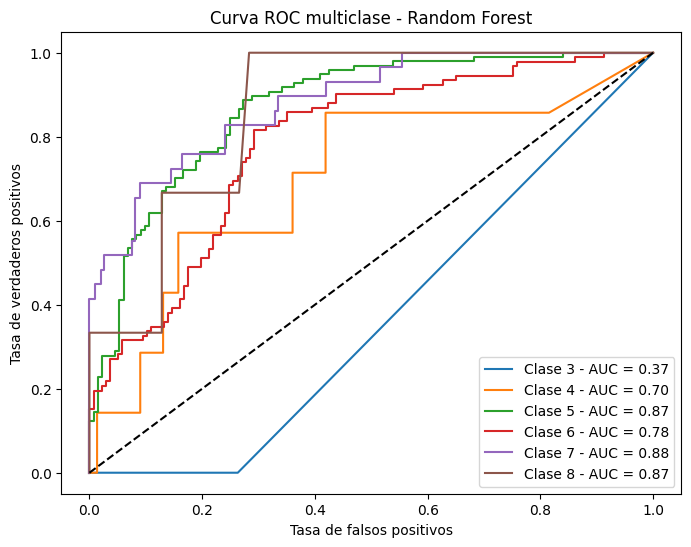

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Mejor modelo seleccionado preliminarmente: Random Forest
clases = sorted(y.unique())

y_test_bin = label_binarize(y_test, classes=clases)
y_score_rf = modelo_rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test_bin,
    y_score_rf,
    average="macro",
    multi_class="ovr"
)

print("AUC macro Random Forest:", round(auc_macro, 3))

plt.figure(figsize=(8,6))

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Clase {clase} - AUC = {roc_auc:.2f}"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC multiclase - Random Forest")
plt.legend()
plt.show()

La curva ROC multicategoría fue construida utilizando el enfoque One-vs-Rest para evaluar la capacidad discriminativa del modelo Random Forest en cada categoría de calidad del vino. El AUC Macro obtenido fue de 0,746, valor que indica una capacidad de discriminación aceptable entre las distintas clases.

Las curvas individuales muestran un mejor desempeño en las categorías con mayor cantidad de observaciones, mientras que las clases menos representadas presentan una capacidad discriminativa más limitada. Este comportamiento es consistente con el desbalance observado en la variable objetivo durante la etapa exploratoria.

En conjunto, el resultado del AUC confirma que Random Forest logra diferenciar razonablemente las categorías de calidad del vino y respalda los hallazgos obtenidos mediante las métricas de clasificación y la matriz de confusión.

| Modelo              | Accuracy | Precision Macro | Recall Macro | F1 Macro |
| ------------------- | -------: | --------------: | -----------: | -------: |
| KNN                 |    0,694 |           0,349 |        0,336 |    0,338 |
| Random Forest       |    0,664 |           0,484 |        0,381 |    0,405 |
| Regresión Logística |    0,437 |           0,302 |        0,393 |    0,278 |


Aunque KNN obtuvo el mayor Accuracy (69,4%), Random Forest alcanzó el mejor equilibrio general entre clases al presentar los mayores valores de Precision Macro (0,484) y F1 Macro (0,405).

**Considerando el desbalance de la variable objetivo, se seleccionó Random Forest como el modelo más adecuado para el problema de clasificación.**


**Conclusión general:**  

Se evaluaron tres algoritmos de clasificación supervisada: KNN, Regresión Logística y Random Forest. Aunque KNN obtuvo el mayor Accuracy (69,4%), Random Forest alcanzó el mejor equilibrio global entre las categorías al registrar el mayor F1 Macro (0,405) y un AUC Macro de 0,746.

Los resultados sugieren que la calidad del vino depende de relaciones complejas entre múltiples características, las cuales son representadas de mejor manera por modelos basados en árboles de decisión que por modelos lineales. Por esta razón, Random Forest fue seleccionado como el modelo más adecuado para este conjunto de datos, al proporcionar el mejor compromiso entre capacidad predictiva, estabilidad y desempeño multiclase.

# **5. Análisis y Comparación de Resultados:**

**5.1 COMPARACIÓN DE MÉTRICAS DE LOS MODELOS**

In [37]:
resultados = pd.DataFrame({
    "Modelo":[
        "KNN",
        "Random Forest",
        "Regresión Logística"
    ],
    "Accuracy":[
        accuracy_knn,
        accuracy_rf,
        accuracy_log
    ],
    "Precision Macro":[
        precision_knn,
        precision_rf,
        precision_log
    ],
    "Recall Macro":[
        recall_knn,
        recall_rf,
        recall_log
    ],
    "F1 Macro":[
        f1_knn,
        f1_rf,
        f1_log
    ]
})

resultados = resultados.round(3)

display(resultados)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,KNN,0.694,0.349,0.336,0.338
1,Random Forest,0.664,0.484,0.381,0.405
2,Regresión Logística,0.437,0.302,0.393,0.278


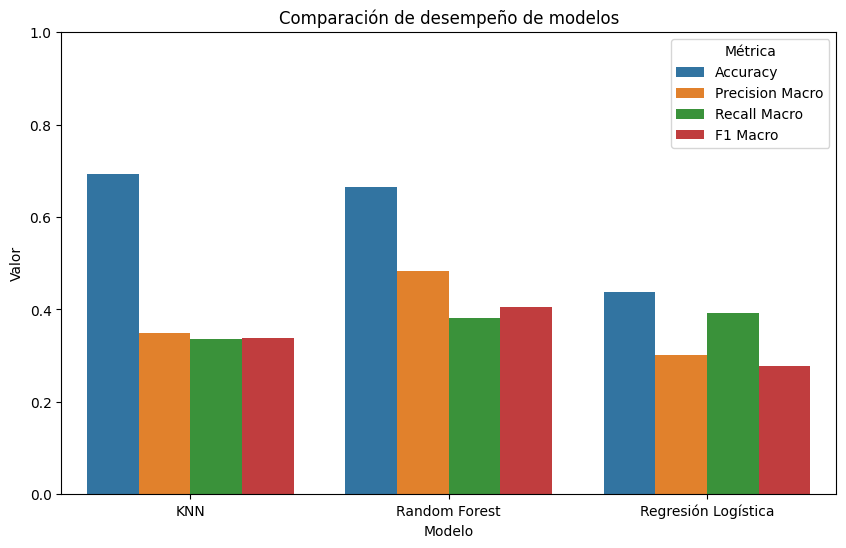

In [38]:
# Gráfico comparativo
resultados_melt = resultados.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=resultados_melt,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación de desempeño de modelos")
plt.ylim(0,1)

plt.show()

**5.2 SELECCIÓN DEL MEJOR MODELO**

In [39]:
print("Modelo seleccionado: Random Forest")
print("Accuracy:", round(accuracy_rf,3))
print("Precision Macro:", round(precision_rf,3))
print("Recall Macro:", round(recall_rf,3))
print("F1 Macro:", round(f1_rf,3))

Modelo seleccionado: Random Forest
Accuracy: 0.664
Precision Macro: 0.484
Recall Macro: 0.381
F1 Macro: 0.405


Aunque KNN obtuvo un Accuracy ligeramente superior (0.694 frente a 0.664), Random Forest fue seleccionado como mejor modelo debido a que alcanzó el mayor F1 Macro (0.405), métrica más adecuada para conjuntos de datos con clases desbalanceadas.

**5.3 IMPORTANCIA DE VARIABLES**

In [77]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

display(importancias)

,Variable,Importancia
10,alcohol,0.146102
1,volatile acidity,0.121388
9,sulphates,0.120889
6,total sulfur dioxide,0.092984
4,chlorides,0.092079
7,density,0.085655
2,citric acid,0.077116
8,pH,0.075209
5,free sulfur dioxide,0.069081
0,fixed acidity,0.065173


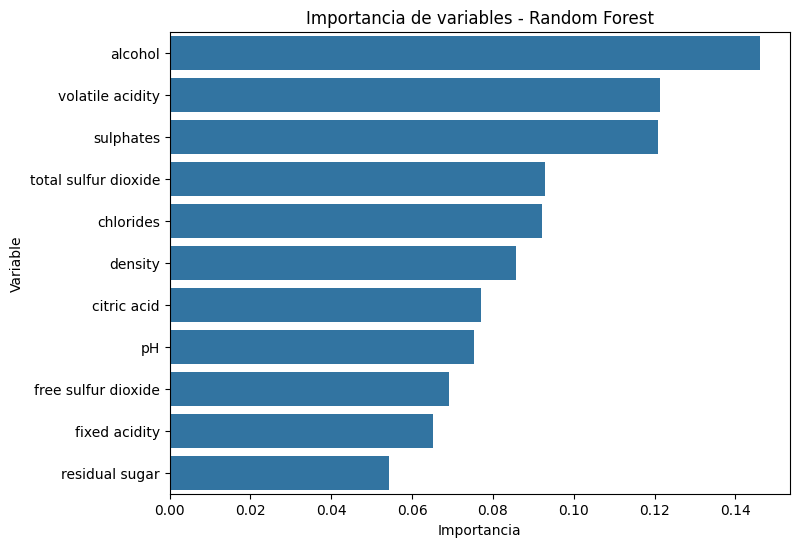

In [78]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")

plt.show()

**5.4 COMPARACIÓN CRÍTICA DE LOS MODELOS**

| Modelo              | Fortalezas                                                      | Debilidades                                         |
| ------------------- | --------------------------------------------------------------- | --------------------------------------------------- |
| KNN                 | Simple, intuitivo, buen accuracy                                | Sensible a escala y al desbalance                   |
| Regresión Logística | Interpretable, rápida                                           | No captura relaciones no lineales                   |
| Random Forest       | Mejor rendimiento global, captura relaciones complejas, robusto | Menor interpretabilidad y mayor costo computacional |


# **6. Conclusiones**

El objetivo de este trabajo fue implementar y comparar distintos modelos de clasificación supervisada para predecir la calidad del vino a partir de sus características físico-químicas, utilizando el conjunto de datos WineQT. Para ello se trabajó con variables como alcohol, volatile acidity, sulphates, chlorides, density, pH, total sulfur dioxide, free sulfur dioxide, fixed acidity, citric acid y residual sugar, las cuales representan atributos comúnmente utilizados en la evaluación de calidad de vinos.

Durante la etapa de preparación de los datos se verificó la ausencia de valores nulos y se eliminó la variable Id por no aportar información útil para la predicción. Además, se realizó una división estratificada entre entrenamiento y prueba con el propósito de conservar la distribución original de las categorías de calidad, y se aplicó escalamiento en aquellos algoritmos que dependen de la magnitud de las variables.

El análisis permitió contrastar tres enfoques diferentes de clasificación. En el caso de K-Nearest Neighbors (KNN), la hipótesis planteaba que vinos con características físico-químicas similares deberían pertenecer a categorías de calidad semejantes. Los resultados mostraron que esta idea se cumple parcialmente, ya que el modelo alcanzó el mayor Accuracy (0,694), demostrando una buena capacidad para identificar correctamente las categorías predominantes. Sin embargo, su desempeño disminuyó al enfrentarse a clases con menor representación, evidenciando sensibilidad al desbalance presente en el conjunto de datos.

Por otra parte, la Regresión Logística fue incorporada como modelo de referencia para evaluar si la calidad del vino podía explicarse mediante relaciones principalmente lineales entre las variables predictoras y la categoría de calidad. Los resultados obtenidos fueron los más bajos de los tres modelos evaluados, con un Accuracy de 0,437 y un F1-score Macro de 0,278. Esto sugiere que la calidad del vino no depende únicamente de relaciones lineales simples, sino que está influenciada por interacciones más complejas entre múltiples características físico-químicas.

Finalmente, la hipótesis asociada a Random Forest fue que la calidad del vino se encuentra determinada por combinaciones no lineales entre variables, donde factores como el contenido de alcohol, la acidez y la composición química interactúan simultáneamente. Los resultados respaldaron esta hipótesis, ya que el modelo obtuvo el mejor equilibrio global de desempeño, alcanzando los mayores valores de Precision Macro (0,484) y F1-score Macro (0,405). Además, las matrices de confusión mostraron una mejor distribución de las predicciones correctas entre las distintas categorías de calidad, mientras que el análisis ROC confirmó una adecuada capacidad de discriminación entre clases.

El análisis de importancia de variables reforzó estos hallazgos. Las variables con mayor influencia en la predicción fueron alcohol, volatile acidity, sulphates y total sulfur dioxide. Estos resultados son coherentes con el conocimiento enológico, ya que el contenido de alcohol suele asociarse a vinos de mejor calidad percibida, mientras que niveles elevados de acidez volátil pueden afectar negativamente las características organolépticas del producto. La relevancia de estas variables demuestra que el modelo fue capaz de identificar factores que efectivamente participan en la determinación de la calidad del vino.

En conclusión, aunque KNN obtuvo el mayor nivel de exactitud global, Random Forest fue seleccionado como el modelo más adecuado para este problema de clasificación. La razón principal es que logró un mejor equilibrio entre precisión, capacidad de generalización y desempeño frente al desbalance de categorías, representado en sus valores superiores de Precision Macro y F1-score Macro. Además, su capacidad para modelar relaciones no lineales permitió representar de mejor manera la complejidad inherente a la calidad del vino, donde múltiples variables físico-químicas interactúan simultáneamente. Como línea de trabajo futura, sería interesante explorar técnicas de balanceo de clases, reducción o agrupación de categorías poco representadas y algoritmos de ensamble más avanzados para mejorar aún más el rendimiento en las clases minoritarias.